*Much of this notebook was adapted from [Kate Follette's course](https://github.com/kfollette/AST200-Spring2020), which itself adapted material from [Mark Krumholz's public course notes](https://sites.google.com/a/ucsc.edu/krumholz/teaching-and-courses/)*

# Fundamentals 6: Control Flow

## Contents
1. The if statement and comparison operators
2. Iteration
3. Exception handling
  

## 1. The if statement 

Now that we know how to define new functions and import them, we're in a position to do some useful programming. However, we need a few more tools. One tool we need the ability to decide what to do based on the input we get. To demonstrate this capability, let's define new module. 

***Enter the following code into a file named plot_trig.py***

```python
# This module plots user-specified trig functions

# Import all the definitions from the numpy and plotting libraries
from numpy import *
from matplotlib.pyplot import *

# Define the plotting function
def makeplot(funcname):

    # Define the x array
    x=arange(0, 2*pi, 0.01)

    # Check if the user entered the sin, cos, or tan function
    if funcname=='sin':
        plot(x, sin(x))
    elif funcname=='cos':
        plot(x, cos(x))
    elif funcname=='tan':
        plot(x, tan(x))
    else:
        print("Unrecognized function "+str(funcname))
        ```
        
Let's examine this module to understand what it does. 

1. We import the numpy and matplotlib.pyplot libraries so that we can use arrays, make plots, etc. Note that we have to import these libraries within the module EVEN IF they have already been imported in our main ipython session. Definitions and import statements are specific to the module where they are called, and functions that are defined or imported into the main session (or the main program, if we're running non-interactively) do not affect other modules, and vice-versa: something that is imported into a given module will not also be imported into the main session.

2. Next, we define a function that takes one argument. This argument is the name of the trig function we are going to plot.

3. Then define an array that goes from 0 to 2 pi with a spacing of 0.01. This is exactly as we did in the last class.

4. Finally, we decide what to do based on the user input, using an if statement. The structure of `if` is fairly simple. We begin a line with `if` and then we follow that with a test that will be either true or false. In this case, we compare the input function name to *sin* and see if it matches.  If the input funcname matches `sin`, we go ahead and plot a sin function. The line to do this is indented another 4 spaces, to indicate that this command belongs within the block to which the if applies.
If the name doesn't match 'sin', we next compare it to *cos*. The statement that does this is `elif`, which is short for 'else if'. The meaning of `elif` is that we first check the if statement. If it is true, we execute the block of code within that if statement. If it is false, we then go on to the `elif` line and do that test. If that test turns out to be true, we execute that block of code. In this case, if the input value of funcname is 'cos', then we will plot a cos function. If the elif turns out to be false, we go on to the next one, that compares the input to 'tan'. If that is true, we plot tan. If not, we encounter an 'else'. The `else` statement is the catchall: it's what we do if all the if's and elif's turn out to be false. In this case, we just print out a message complaining that we don't recognize the input function.

For this code to work, we also have to tell Jupyter to put any plots created by python into the notebook directly. You will use this command in most of the notebooks that we use in this class

In [ ]:
%pylab inline

OK, let's test this code out:

In [ ]:
import plot_trig as pt

In [ ]:
pt.makeplot('sin')

Hopefully you see something like this:

<img src="fundamentals6_sin.png" alt="Plotting file fundamentals6_sin.png" width="500"/>

Try experimenting with the other trig functions to verify that they work. 

This is a good chance to practice adding cells with your Jupyter shortcut sheet as well. 

## Exercise 1
-----------------------

Add a function to your `mymodule` file called hellox that meets the criteria laid out below. 

Save it, reimport your module, and create test statements calling the function that demonstrate each of the capabilties.

1. Has one required variable (`name`) and one optional variable (`grade`) with a default value of B
2. prints 
 - "Hello *name*. Your grade for this exercise is *grade*.", 
 
where `name` and `grade` are the inputs described in 1
3. If `name` is "Winters", print "Hello Professor Winters! I LOVE python!!"
4. If `name` has three or fewer characters, print nothing (the python "len" function will be useful here. Pull up the docstring to learn how to use it.)
5. If `name` is "Maria", set `grade` to A+.
6. If the first letter of `name` is P, set grade to C-. Note that you can index strings just like arrays.

*Challenge exercise (not required but try it)*:  
If the third from last letter of `name` is a vowel, set grade to F.

## 2 Iteration

The next tool we want to add to our arsenal of programming tools is iteration. 

Iteration means performing an operation repeatedly. 

Let's start by making a list of objects as follows...

In [ ]:
names = ['Henrietta', 'Annie', 'Jocelyn', 'Vera']

## 2.1 `for` loop

We can now use a `for` loop to *iteratively* print out each item:

In [ ]:
for n in names:
    print('There are '+str(len(n))+' letters in '+n)

This is an example of a *for loop*. 

The way a for loop works is a follows. 
 - We start with a list of objects -- in this example a list of strings, but it could be anything.
 - Then we say "for variable in list:", 
 - Followed by a block of code. 
   - The code inside the block will be executed once for every item in the list.
   - When it is executed the variable will be set equal to the appropriate list item. 
   - In this example, the list names had four objects in it, each a string. Thus the print statement inside the loop was executed four times. The first time it was executed, the variable n was set equal to alice. The second time n was set equal to bob, then charlie, then dana.

One of the most common types of loop is where you want to loop over numbers: 0, 1, 2, 3, .... 

To handle loops of this sort, python provides a simple command to construct a list of numbers to iterate over, called range. The command range(n) produces a list of numbers from 0 to n-1. For example:

In [ ]:
for i in range(5):
    print(i)

Note that the range command has exactly the same syntax as the arange command we encountered when we constructed arrays. The difference is that arange returns an array, and range returns a list; we'll clarify the difference between those two in a few minutes.

That's really all there is to for loops. To demonstrate their utility, let's say we want to extend the capability of our trigonometric function plotting tool so that a user has the option to plot multiple trig functions with different wavelengths. To implement this, ***open up your plot_trig.py file and edit it as follows***:

```python
# This module plots user-specified trig functions

# Import all the definitions from the numpy and plotting libraries
from numpy import *
from matplotlib.pyplot import *

# Define the plotting function
def makeplot(funcname, wavelength=[2*pi]):

    # Define the x array
    x=arange(0, 2*pi, 0.01)

    # Loop over wavelengths
    for w in wavelength:

        # Check if the user entered the sin, cos, or tan function
        if funcname=='sin':
            plot(x, sin(x*2*pi/w))
        elif funcname=='cos':
            plot(x, cos(x*2*pi/w))
        elif funcname=='tan':
            plot(x, tan(x*2*pi/w))
        else:
            print("Unrecognized function "+str(funcname))
            return
            ```
            
Notice first that we've made use of our optional argument capability. The user can enter a wavelength value, but doesn't have to, because the wavelength will default to 2 pi. If the user does enter a set of wavelengths, we've used a loop to iterate over them. Let's try running this code (remembering to reload the module first, and, if you want, to clear the plot window with clf()):

In [ ]:
from imp import reload
reload(pt)

In [ ]:
pt.makeplot('sin',[pi,2*pi,3*pi])

Hopefully the result looks like this:
<img src="fundamentals6_multi.png" alt="Plotting file fundamentals6_multi.png" width="500"/>

## 2.2 `while` loop


There are also other ways of iterating, which may be more convenient depending on what you're trying to do. 

A very common one is the `while` loop, which does exactly what it sounds like it should: it loops until some condition is met. For example:

In [ ]:
i=0
while i < 11:
    print(i)
    i=i+3

The `while` syntax:, 
 - The condition is anything that evaluates to True or False. 
 - When you make a while statement, the condition is checked.
   - If it is True, the code inside the while block is executed. 
 - Then the condition is checked again. 
   - If it is still True, the code inside the block is executed again, and so forth, until the condition evaluates to False. 
 - In this example, the condition is true when i is 0, 3, 6, and 9, but then i is set to 12 and the condition is False, so the loop halts.
 - You whould be aware that it is easy to accidentally create while-loops that go on for ever, which is bad, as your computer doesn't know to stop calculating ...

## Exercise 2
-------------------
Using a loop, write a function that will return the factorial of a number.
 - Reminder: $n! = n*(n-1)*(n-2)*...*1$
 - E.g. $4! = 4*3*2*1 = 24$
 
Make sure that you *test you function*: does it give the result you expect for some simple examples? 

## 3 Exception handling

The final control flow tool we'll play with today is exception handling. To see why we might want this capability, let's do what a user might well do when using the wavelength capability, which is to specify a single wavelength rather than a list:

In [ ]:
pt.makeplot('sin',wavelength=2*pi)

We get an error message! Why? Because the code we have written wants to iterate over wavelength, but if the user enters a single number for the wavelength, as opposed to a list, that's not a list we can iterate over.

How can we handle this? We can catch this sort of error and handle it. The capability to detect and recover from errors is called exception handling. There are many ways we could use this capability to handle this situation. Let's implement one. 

***Modify your plottrig.py file as follows:***

```python

# This module plots user-specified trig functions

# Import all the definitions from the numpy and plotting libraries
from numpy import *
from matplotlib.pyplot import *

# Define the plotting function
def makeplot(funcname, wavelength=[2*pi]):

    # Define the x array
    x=arange(0, 2*pi, 0.01)

    # Try to loop over wavelengths to make sure it's possible. If not,
    # turn wavelengths into a list.
    try:
        for w in wavelength:
            pass
    except TypeError:
        wavelength=[wavelength]

    # Loop over wavelengths
    for w in wavelength:

        # Check if the user entered the sin, cos, or tan function
        if funcname=='sin':
            plot(x, sin(x*2*pi/w))
        elif funcname=='cos':
            plot(x, cos(x*2*pi/w))
        elif funcname=='tan':
            plot(x, tan(x*2*pi/w))
        else:
            print("Unrecognized function "+str(funcname))
            return

```

The difference between this and the last version is the bit of code

```python
    # Try to loop over wavelengths to make sure it's possible. If not,
    # turn wavelengths into a list.
    try:
        for w in wavelength:
            pass
    except TypeError:
        wavelength=[wavelength]
```

Let's break this down into pieces. 
 - First, we have a line that says `try:`. 
   - The try statement is a declaration that we're about to try something that may generate an error, and, if it does, we want to decide what to do based on that error. 
 - The try statement is followed by the block of code that might generate the error. 
   - In this case, we're going to try to loop over wavelength. 
   - We won't actually do anything -- we just want to see if it's *possible* to perform the loop. 
 - The `pass` statement is a statement that does nothing. 
   - It's just a placeholder, inserted because there has to be something inside the for loop. 
 - Finally, we get to the line `except TypeError:`. 
   - This line ends the try block, and its purpose is to specify what we do if we get an error. 
   - The syntax is that we say except, and then we list one or more types of errors we want to handle. 
   - In this case, we want to handle TypeErrors, which arise (among other things) when we try to iterate over something that is not iterable. 
 - The final line specified what we do if we generate an error of this sort. 
   - The answer is that we turn wavelength into a list of one element, so that we can iterate over it. 
 - Then execution continues as before.

Now let's verify that this works:

In [19]:
reload(pt)

<module 'plot_trig' from '/Users/matthewjohnpayne/git_repos/BSU422/A_fundamentals/plot_trig.py'>

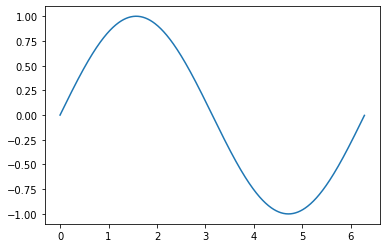

In [20]:
pt.makeplot('sin',wavelength=2*pi)

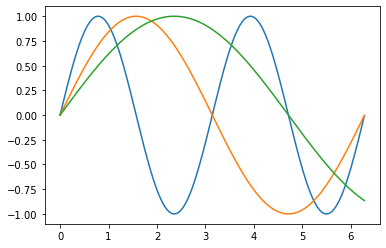

In [21]:
pt.makeplot('sin',[pi,2*pi,3*pi])

As demonstrated above, we can now make either a single plot or multiple plots. 

## Exercise 3
-------------------
1. Write a function named `sq` that takes in a variable, `n`, and prints out the value of $n^2$.
2. Think about what will happen if someone inputs a *number* and what will happen if someone inputs a *string*
3. Add a try-exception catch that (a) tries to print out the square of the number as above, and (b) if this fails, prints out a message saying, "the input `n` of type `type(n)` cannot be squared"
4. Demonstrate this for numerical and string inputs 